In [1]:
using DifferentialEquations, LinearAlgebra
using Statistics, Folds
using Plots, LaTeXStrings
using JLD2
using Convex
BLAS.set_num_threads(1)

In [2]:
function sampleSpinZPlus()
    θ = acos(1/sqrt(3))
    ϕ = 2π * rand()
    return θ, ϕ
end

function sampleSpinZMinus()
    θ = π - acos(1/sqrt(3))
    ϕ = 2π * rand()
    return θ, ϕ
end

function sampleFullyMixed()
    θ = π * rand()
    ϕ = 2π * rand()
    return θ, ϕ
end

sampleFullyMixed (generic function with 1 method)

In [3]:
function prob_func(prob, i, repeat)
    u0 = Vector{Float64}(undef, 2 * nAtoms)
    r = 6
    for n in 1:nAtoms
        if n == r
            θn, ϕn = sampleSpinZPlus()
        else
            θn, ϕn = sampleSpinZMinus()
        end
        u0[n] = θn
        u0[nAtoms + n] = ϕn
    end
    remake(prob, u0=u0)
end

prob_func (generic function with 1 method)

In [4]:
function drift!(du, u, p, t)
    Ω, J, Γ, Κ = p
    α = 6
    θ = u[1:nAtoms]
    ϕ = u[nAtoms .+ (1:nAtoms)]

    for n = 1:nAtoms
        dθ_drift = 0.0
        dϕ_drift = 0.0
        dϕ_drift_sum = 0.0
        dθ_drift = -2 * Ω * sin(-ϕ[n]) + Γ * (cot(π - θ[n]) - csc(π - θ[n]) / sqrt(3))
        for m = 1:nAtoms
            if m !== n
                dϕ_drift_sum += (1 - sqrt(3) * cos(π - θ[m]))/abs(m - n)^α
            end
        end
        dϕ_drift = - (2 * Ω * cot(π - θ[n]) * cos(-ϕ[n]) + J / 2 * dϕ_drift_sum)
        du[n] = dθ_drift
        du[n + nAtoms] = dϕ_drift
    end
    nothing
end
function diffusion!(du, u, p, t)
    Ω, J, Γ, Κ = p
    θ = u[1:nAtoms]
    ϕ = u[nAtoms .+ (1:nAtoms)]
    for n = 1:nAtoms
        du[n] = 0.0
        du[nAtoms + n] = sqrt(1 / 2 * Γ * (1 + 2 * cot(π - θ[n])^2 + (2 * cot(π - θ[n]) * csc(π - θ[n])/sqrt(3))) + 4 * Κ)
    end
    nothing
end

diffusion! (generic function with 1 method)

In [5]:
function computeTWA(nAtoms, tf, nT, nTraj, dt)
    tspan = (0, tf)
    tSave = LinRange(0, tf, nT)
    u0 = zeros(2 * nAtoms)
    p = (Ω, J, Γ, Κ, nAtoms) 
    prob = SDEProblem(drift!, diffusion!, u0, tspan, p, noise_rate_prototype=zeros(2 * nAtoms, 2))
    ensemble_prob = EnsembleProblem(prob; prob_func=prob_func)
    alg = EM()
    sol = solve(ensemble_prob, alg, EnsembleThreads();
        saveat=tSave, trajectories=nTraj, maxiters=1e+7, dt=dt,
        abstol=1e-5, reltol=1e-5)
    return tSave, sol
end

computeTWA (generic function with 1 method)

In [15]:
Ω = 0.3
J = Ω / 3
Γ = 0.01 * J
Κ = 0.01 * J
tf = 20
nT = 100
nTraj = 50
dt = 1e-3
nAtoms = 9
p = (Ω, J, Γ, Κ, nAtoms)
@time t,sol = computeTWA(nAtoms, tf, nT, nTraj, dt)

 24.201032 seconds (1.10 G allocations: 18.509 GiB, 21.33% gc time)


(LinRange{Float64}(0.0, 20.0, 100), EnsembleSolution{Float64, 3, Vector{RODESolution{Float64, 2, Vector{Vector{Float64}}, Nothing, Nothing, Vector{Float64}, NoiseProcess{Float64, 2, Float64, Vector{Float64}, Nothing, Nothing, typeof(DiffEqNoiseProcess.INPLACE_WHITE_NOISE_DIST), typeof(DiffEqNoiseProcess.INPLACE_WHITE_NOISE_BRIDGE), Nothing, true, ResettableStacks.ResettableStack{Tuple{Float64, Vector{Float64}, Nothing}, true}, ResettableStacks.ResettableStack{Tuple{Float64, Vector{Float64}, Nothing}, true}, RSWM{Float64}, Nothing, RandomNumbers.Xorshifts.Xoroshiro128Plus}, SDEProblem{Vector{Float64}, Tuple{Float64, Float64}, true, Tuple{Float64, Float64, Float64, Float64, Int64}, Nothing, SDEFunction{true, SciMLBase.FullSpecialize, typeof(drift!), typeof(diffusion!), UniformScaling{Bool}, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, typeof(SciMLBase.DEFAULT_OBSERVED), Nothing, Nothing}, typeof(diffusion!), Base.Pairs{Symbol, Union{}

In [16]:
function compute_spin_Sz(sol, nAtoms)
    θ = sol[1:nAtoms, :, :]
    ϕ = sol[nAtoms+1:2*nAtoms, :, :]
    Szs = sqrt(3) * sum(cos.(θ), dims=1)[1, :, :] / 2
    Sz = mean(Szs, dims=2)[:]

    Sxs = sqrt(3) * sum(sin.(θ) .* cos.(ϕ), dims=1)[1, :, :] / 2
    Sys = sqrt(3) * sum(sin.(θ) .* sin.(ϕ), dims=1)[1, :, :] / 2
    Szs = sqrt(3) * sum(cos.(θ), dims=1)[1, :, :] / 2
    Sms = Sxs - im * Sys 

    Sx = mean(Sxs, dims=2)[:]
    Sy = mean(Sys, dims=2)[:]
    Sz = mean(Szs, dims=2)[:]
    S2 = mean(abs2.(Sxs) + abs2.(Sys) + abs2.(Szs), dims=2)[:]
    W = mean(abs2.(Sms), dims=2)[:] + Sz
    return Sz, W
end

compute_spin_Sz (generic function with 1 method)

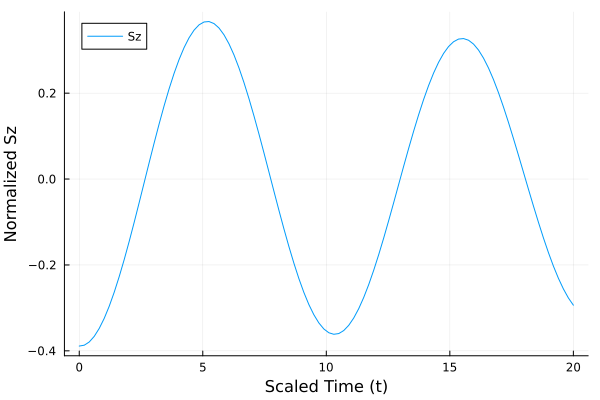

In [17]:
Sz_vals, W = compute_spin_Sz(sol, nAtoms)
# @save "DickeTWA_n=$(nAtoms).jld2" Sz_vals W

plot(t, Sz_vals/nAtoms, 
     label="Sz",
     xlabel="Scaled Time (t)", 
     ylabel="Normalized Sz",
     )

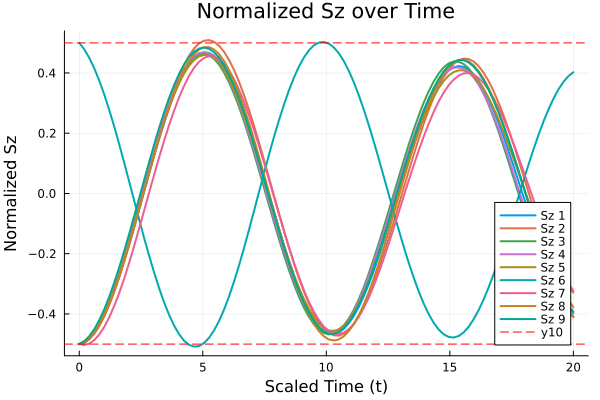

In [18]:
function compute_spin_Sz(sol, nAtoms)
    θ = sol[1:nAtoms, :, :]
    ϕ = sol[nAtoms+1:2*nAtoms, :, :]
    
    Szs = sqrt(3) * cos.(θ) / 2
    return Szs
end
Sz_vals = compute_spin_Sz(sol, nAtoms);
Sz_vals = mean(Sz_vals, dims=3);
# @save "DickeTWA_n=$(nAtoms).jld2" Sz_vals W
plot()

# Loop through each row in Sz_vals and plot
for i in 1:size(Sz_vals, 1)
    plot!(t, Sz_vals[i, :],
        label="Sz $(i)",  # Label for each row
        linewidth=2,
    )  # Set the line width
end
hline!([-0.5, 0.5], line=(:red, :dash))

# Additional plot settings
xlabel!("Scaled Time (t)")
ylabel!("Normalized Sz")
title!("Normalized Sz over Time")